# [Physics-Informed Neural Networks](https://de.mathworks.com/discovery/physics-informed-neural-networks.html)
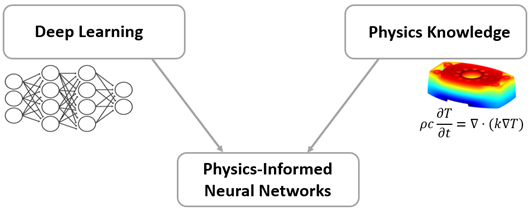





In [18]:
import functools
import matplotlib.pyplot as plt
import numpy as np
import torch
import seaborn as sns
import torch.nn as nn
import torch.optim as optim

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

sns.set_theme()
torch.manual_seed(42)

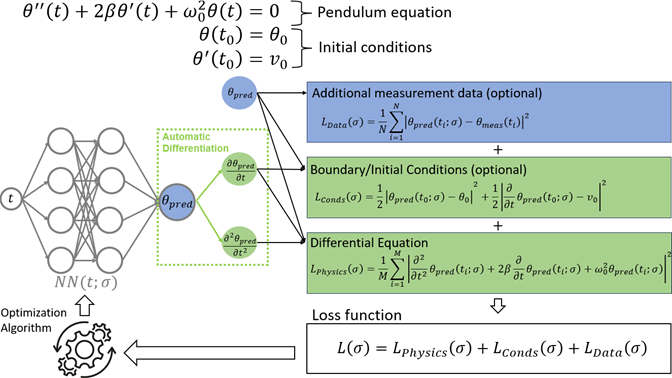

In [19]:
def grad(outputs, inputs):
    """Computes the partial derivative of 
    an output with respect to an input.
    Args:
        outputs: (N, 1) tensor
        inputs: (N, D) tensor
    """
    return torch.autograd.grad(
        outputs, inputs, grad_outputs=torch.ones_like(outputs), create_graph=True
    )

In [20]:
def pendulum_law(time, m, k, D, x0):
    delta = k / (2*m)
    w = np.sqrt(D/m - delta**2)
    
    return x0 * np.exp(-delta*time) * (np.cos(w*time) + (delta/w) * np.sin(w*time))

Text(0.5, 0, 'Time (s)')

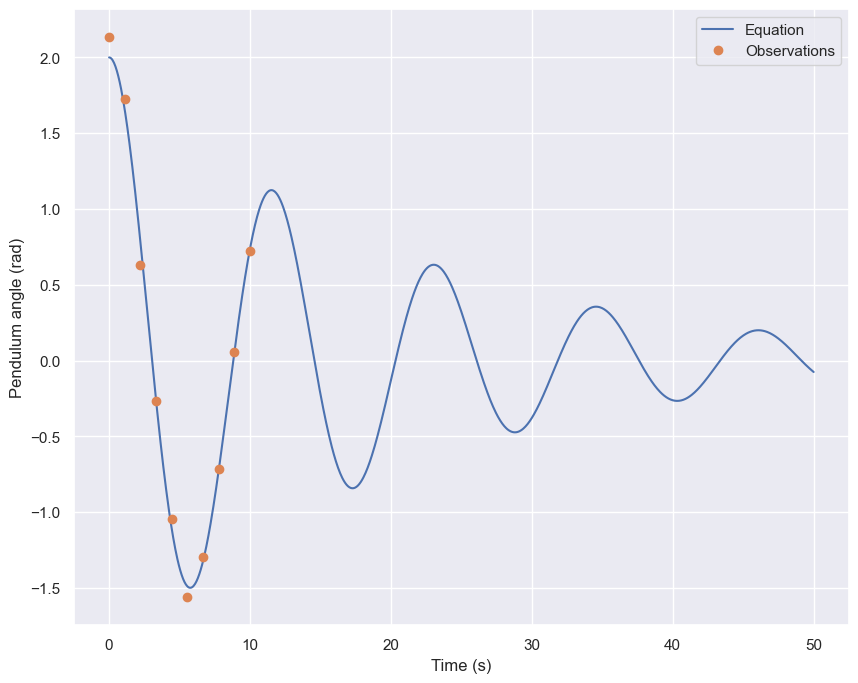

In [21]:
np.random.seed(10)

m = 10
k = 1
D = 3
x0 = 2
time = np.linspace(0, 50, 1001)
eq = functools.partial(pendulum_law, m=m, k=k, D=D, x0=x0)
y = eq(time)

tm = np.linspace(0, 10, 10)
ym = eq(tm) + 0.1 * np.random.randn(10)

plt.gcf().set_size_inches(10, 8)
plt.plot(time, y)
plt.plot(tm, ym, 'o')
plt.legend(['Equation', 'Observations'])
plt.ylabel('Pendulum angle (rad)')
plt.xlabel('Time (s)')

In [22]:
def np_to_th(x):
    """Convert a NumPy array to a 2D float32 PyTorch tensor on the configured device.

    Args:
        x: NumPy array of shape (n_samples, ...).

    Returns:
        torch.Tensor: Float32 tensor of shape (n_samples, -1) on DEVICE.
    """
    n_samples = len(x)
    return torch.from_numpy(x).to(torch.float).to(DEVICE).reshape(n_samples, -1)

In [23]:
class Net(nn.Module):
    """Feedforward neural network for regression, supporting an optional physics-informed
    auxiliary loss term.

    The architecture consists of four hidden layers with Tanh activations followed by a
    linear output layer.
    """

    def __init__(
        self,
        input_dim,
        output_dim,
        n_units=100,
        epochs=1000,
        loss=nn.MSELoss(),
        lr=1e-3,
        loss2=None,
        loss2_weight=0.1,
        input_scale=1.0,
    ) -> None:
        """Initialise the network.

        Args:
            input_dim (int): Number of input features.
            output_dim (int): Number of output features.
            n_units (int): Number of units in each hidden layer. Defaults to 100.
            epochs (int): Number of training epochs. Defaults to 1000.
            loss (nn.Module): Primary loss function. Defaults to MSELoss.
            lr (float): Learning rate for the Adam optimiser. Defaults to 1e-3.
            loss2 (callable | None): Optional secondary physics loss callable
                ``loss2(model) -> Tensor``. Defaults to None.
            loss2_weight (float): Weighting factor for the secondary loss. Defaults to 0.1.
            input_scale (float): Scaling factor for the input (e.g. t_max). Defaults to 1.0.
        """
        super().__init__()

        self.epochs = epochs
        self.loss = loss
        self.loss2 = loss2
        self.loss2_weight = loss2_weight
        self.lr = lr
        self.n_units = n_units
        self.input_scale = input_scale

        self.layers = nn.Sequential(
            nn.Linear(input_dim, self.n_units),
            nn.Tanh(),
            nn.Linear(self.n_units, self.n_units),
            nn.Tanh(),
            nn.Linear(self.n_units, self.n_units),
            nn.Tanh(),
            nn.Linear(self.n_units, self.n_units),
            nn.Tanh(),
        )
        self.out = nn.Linear(self.n_units, output_dim)

    def forward(self, x):
        """Perform a forward pass through the network.

        Args:
            x (torch.Tensor): Input tensor of shape (batch_size, input_dim).

        Returns:
            torch.Tensor: Output tensor of shape (batch_size, output_dim).
        """
        x = x / self.input_scale
        h = self.layers(x)
        out = self.out(h)

        return out

    def fit(self, X, y):
        """Train the network using the Adam optimiser.

        Args:
            X (np.ndarray): Input features of shape (n_samples, input_dim).
            y (np.ndarray): Target values of shape (n_samples, output_dim).

        Returns:
            list[float]: Per-epoch loss values.
        """
        Xt = np_to_th(X)
        yt = np_to_th(y)

        optimiser = optim.Adam(self.parameters(), lr=self.lr)
        self.train()
        losses = []
        for ep in range(self.epochs):
            optimiser.zero_grad()
            outputs = self.forward(Xt)
            loss = self.loss(yt, outputs)
            if self.loss2:
                loss += self.loss2_weight * self.loss2(self)
            loss.backward()
            optimiser.step()
            losses.append(loss.item())
            if ep % int(self.epochs / 10) == 0:
                print(f"Epoch {ep}/{self.epochs}, loss: {losses[-1]:.4e}")
        return losses

    def predict(self, X):
        """Run inference on new data.

        Args:
            X (np.ndarray): Input features of shape (n_samples, input_dim).

        Returns:
            np.ndarray: Predicted values of shape (n_samples, output_dim).
        """
        self.eval()
        out = self.forward(np_to_th(X))
        return out.detach().cpu().numpy()


Epoch 0/20000, loss: 1.4265e+00
Epoch 2000/20000, loss: 9.1048e-05
Epoch 4000/20000, loss: 5.8395e-06
Epoch 6000/20000, loss: 1.2710e-11
Epoch 8000/20000, loss: 3.7572e-09
Epoch 10000/20000, loss: 6.8445e-15
Epoch 12000/20000, loss: 9.9698e-15
Epoch 14000/20000, loss: 4.6241e-15
Epoch 16000/20000, loss: 2.7157e-14
Epoch 18000/20000, loss: 3.9094e-13


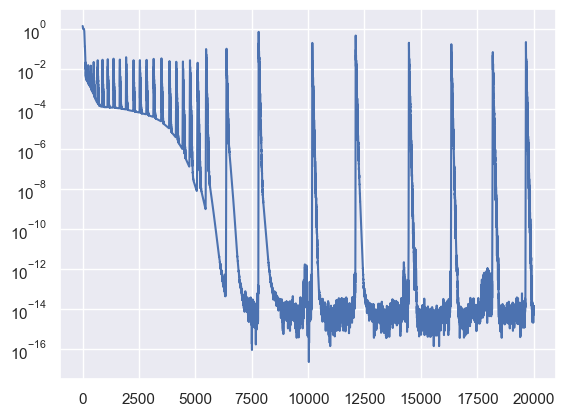

In [24]:
net = Net(1, 1, loss2=None, epochs=20000, lr=1e-3, input_scale=50.0).to(DEVICE)

losses = net.fit(tm, ym)

plt.plot(losses)
plt.yscale('log')


Text(0.5, 0, 'Time (s)')

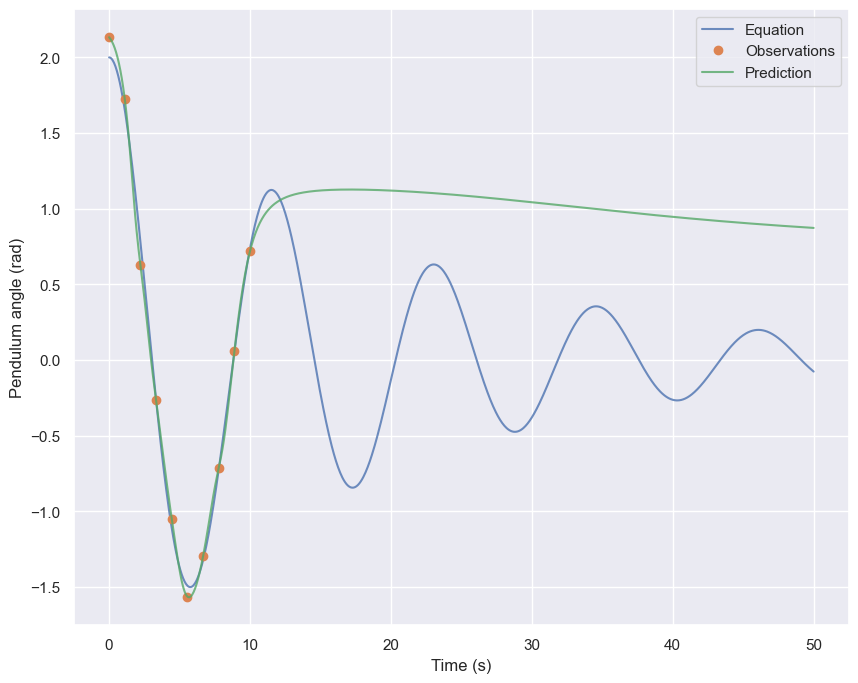

In [25]:

preds = net.predict(time)

plt.gcf().set_size_inches(10, 8)
plt.plot(time, y, alpha=0.8)
plt.plot(tm, ym, 'o')
plt.plot(time, preds, alpha=0.8)

#plt.gca().set_ylim(-2, 5)
plt.legend(labels=['Equation','Observations', 'Prediction'])
plt.ylabel('Pendulum angle (rad)')
plt.xlabel('Time (s)')

In [30]:

def physics_loss(model: torch.nn.Module):
    ts = torch.linspace(0, 50, steps=1001,).view(-1,1).requires_grad_(True).to(DEVICE)
    theta = model(ts)
    dtheta_dt = grad(theta, ts)[0]
    d2theta_dt2 = grad(dtheta_dt, ts)[0]
    pde = d2theta_dt2 + (k/m) * dtheta_dt + (D/m) * theta
    return torch.mean(pde**2)

physics_loss(net)


tensor(0.0871, device='cuda:0', grad_fn=<MeanBackward0>)

Epoch 0/50000, loss: 1.4326e+00
Epoch 5000/50000, loss: 2.9099e-03
Epoch 10000/50000, loss: 2.2138e-03
Epoch 15000/50000, loss: 2.1557e-03
Epoch 20000/50000, loss: 2.1135e-03
Epoch 25000/50000, loss: 2.0710e-03
Epoch 30000/50000, loss: 3.5829e-03
Epoch 35000/50000, loss: 2.0699e-03
Epoch 40000/50000, loss: 2.0661e-03
Epoch 45000/50000, loss: 2.0643e-03


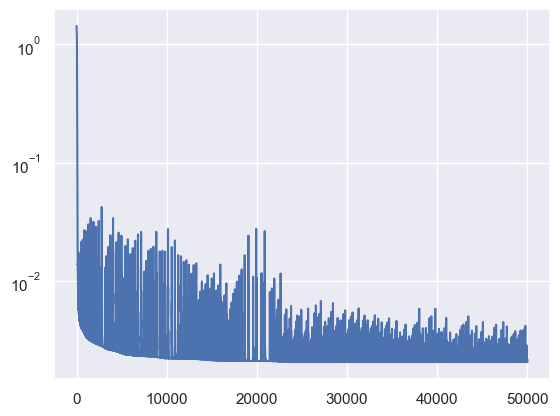

In [31]:
net = Net(1, 1, loss2=physics_loss, epochs=50000, loss2_weight=1, lr=1e-3, input_scale=50.0).to(DEVICE)

losses = net.fit(tm, ym)
plt.plot(losses)
plt.yscale('log')


Text(0.5, 0, 'Time (s)')

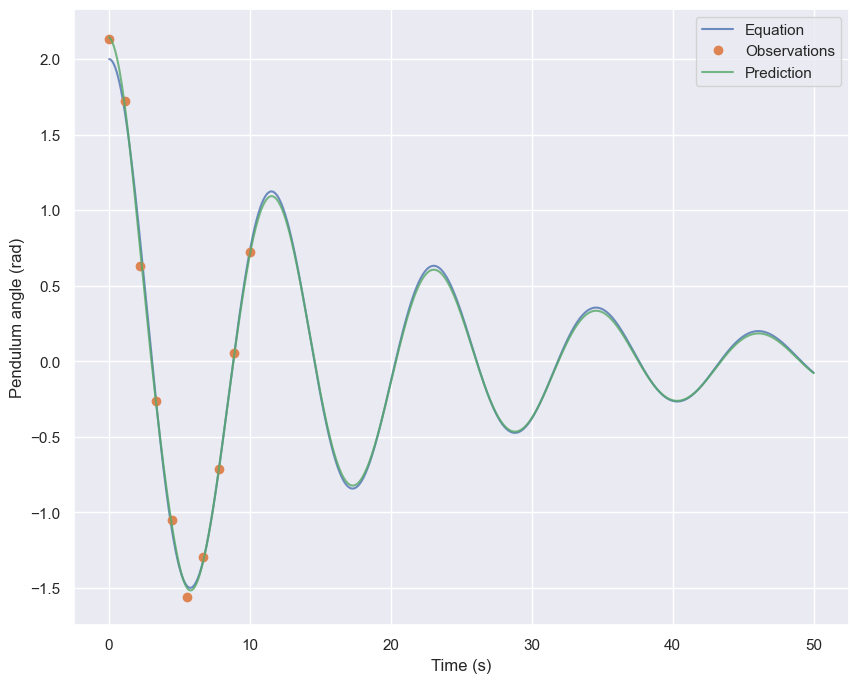

In [32]:
preds = net.predict(time)

plt.gcf().set_size_inches(10, 8)
plt.plot(time, y, alpha=0.8)
plt.plot(tm, ym, 'o')
plt.plot(time, preds, alpha=0.8)


plt.legend(labels=['Equation','Observations', 'Prediction'])
plt.ylabel('Pendulum angle (rad)')
plt.xlabel('Time (s)')

In [10]:
class NetDiscovery(Net):
    def __init__(
        self,
        input_dim,
        output_dim,
        n_units=100,
        epochs=1000,
        loss=nn.MSELoss(),
        lr=0.001,
        loss2=None,
        loss2_weight=0.1,
        input_scale=1.0,
    ) -> None:
        super().__init__(
            input_dim, output_dim, n_units, epochs, loss, lr, loss2, loss2_weight, input_scale
        )

        self.D = nn.Parameter(data=torch.tensor([0.]))

In [13]:
def physics_loss_discovery(model: torch.nn.Module):
    ts = torch.linspace(0, 50, steps=1001,).view(-1,1).requires_grad_(True).to(DEVICE)
    theta = model(ts)
    dtheta_dt = grad(theta, ts)[0]
    d2theta_dt2 = grad(dtheta_dt, ts)[0]
    pde = d2theta_dt2 + (k/m) * dtheta_dt + (model.D/m) * theta
    return torch.mean(pde**2)

c:\Users\yuw1si\.conda\envs\my_space\Lib\site-packages\torch\autograd\graph.py:841: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:270.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch 0/50000, loss: 1.4265e+00
Epoch 5000/50000, loss: 2.7362e-03
Epoch 10000/50000, loss: 2.2863e-03
Epoch 15000/50000, loss: 2.2440e-03
Epoch 20000/50000, loss: 2.5100e-03
Epoch 25000/50000, loss: 2.0492e-03
Epoch 30000/50000, loss: 2.0547e-03
Epoch 35000/50000, loss: 2.0458e-03
Epoch 40000/50000, loss: 2.0519e-03
Epoch 45000/50000, loss: 2.0518e-03


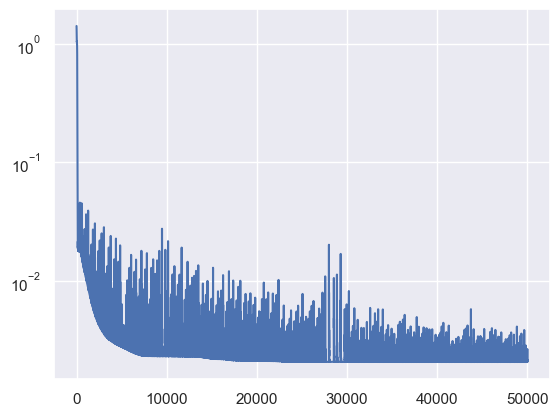

In [15]:
net = NetDiscovery(1, 1, loss2=physics_loss_discovery, epochs=50000, loss2_weight=1, lr=1e-3, input_scale=50.0).to(DEVICE)

losses = net.fit(tm, ym)
plt.plot(losses)
plt.yscale('log')

In [17]:
net.D.item()    

2.8940184116363525

Text(0.5, 0, 'Time (s)')

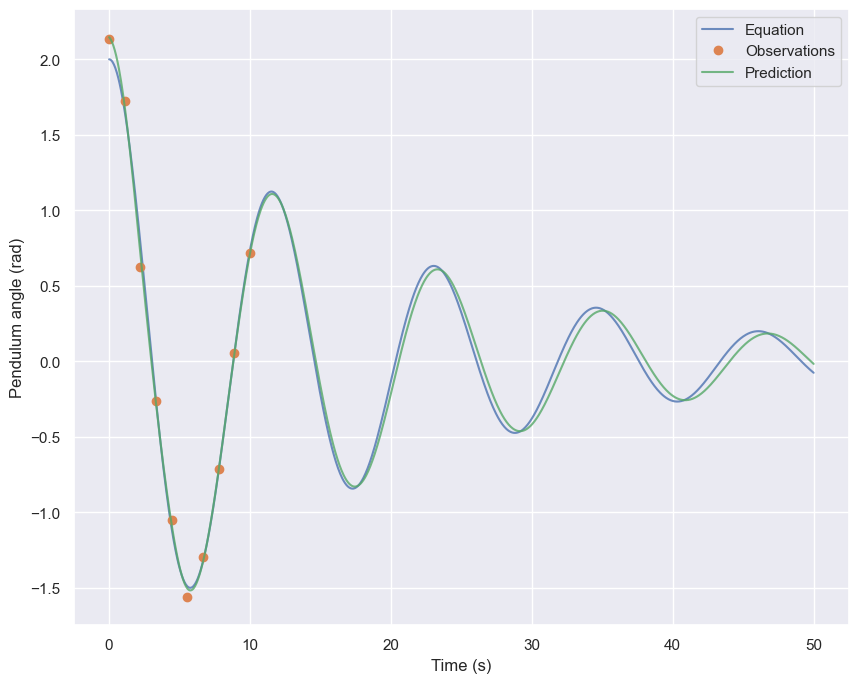

In [16]:
preds = net.predict(time)

plt.gcf().set_size_inches(10, 8)
plt.plot(time, y, alpha=0.8)
plt.plot(tm, ym, 'o')
plt.plot(time, preds, alpha=0.8)


plt.legend(labels=['Equation','Observations', 'Prediction'])
plt.ylabel('Pendulum angle (rad)')
plt.xlabel('Time (s)')

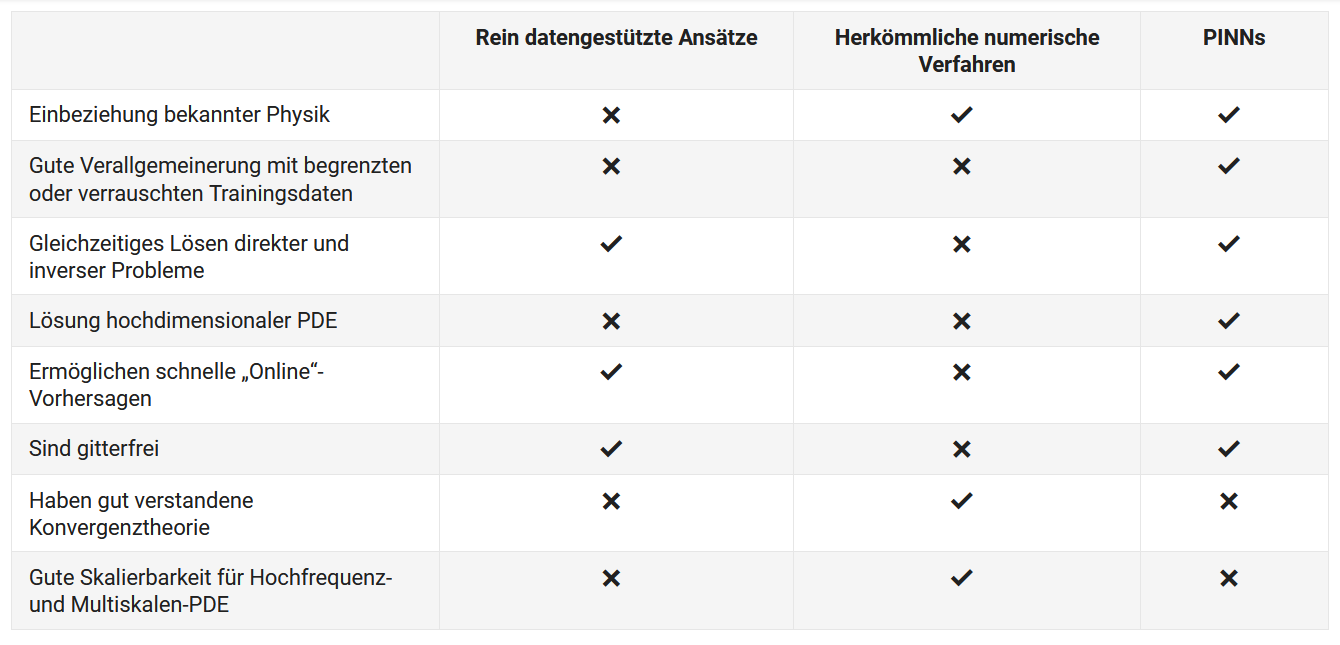